# Task 2 & 3: Build Time Series Forecasting Models and Predict Future Trends

This notebook builds, tunes, and compares an **ARIMA/SARIMA** model and a **PyTorch LSTM** model to forecast Tesla's stock price. Then, we use the best-performing model to forecast future prices (6-12 months out) with confidence intervals.

In [1]:
import sys
sys.path.append('../')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from src.data_loader import load_local_data
from src.models import (
    calculate_metrics, fit_auto_arima, prepare_lstm_data,
    train_lstm, forecast_lstm_test, forecast_lstm_future
)

## 1. Prepare Data for Modeling (Train-Test Split)
We split the TSLA data chronologically. Train: 2015-2024, Test: 2025-2026.

In [2]:
data_dict = load_local_data(["TSLA"], input_dir="../data/processed")
tsla_close = data_dict["TSLA"]['Adj Close']

train_split_date = "2025-01-01"
train_close = tsla_close[:train_split_date]
test_close = tsla_close[train_split_date:]

print(f"Train size: {len(train_close)}, Test size: {len(test_close)}")

Train size: 2516, Test size: 372


## 2. Classical ARIMA/SARIMA Model

In [3]:
# Find optimal order and fit
arima_model = fit_auto_arima(train_close, m=1)
arima_order = arima_model.order
arima_seasonal_order = arima_model.seasonal_order

# Fit statsmodels SARIMAX
model_sm = SARIMAX(train_close, order=arima_order, seasonal_order=arima_seasonal_order)
fitted_sm = model_sm.fit(disp=False)

# Forecast on test period
arima_test_preds = fitted_sm.forecast(steps=len(test_close))
arima_test_preds.index = test_close.index

Fitting auto_arima...
Performing stepwise search to minimize aic


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=1.54 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.13 sec


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.04 sec


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.28 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.238 seconds
Best ARIMA order: (0, 1, 0) Seasonal order: (0, 0, 0, 0)


C:\Users\arsema\Desktop\New folder\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\arsema\Desktop\New folder\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\arsema\Desktop\New folder\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\arsema\Desktop\New folder\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No s

## 3. Deep Learning LSTM Model (PyTorch)
We frame this as a 60-day lag problem: predict today's price using the last 60 days of prices.

In [4]:
window_size = 60
X_train, y_train, scaler = prepare_lstm_data(train_close, window_size)
lstm_model, device = train_lstm(X_train, y_train, epochs=20, batch_size=32, lr=0.001)

# Prepare test dataset with overlap of last 60 days from training
lstm_full_series = pd.concat([train_close[-window_size:], test_close])
X_test, y_test, _ = prepare_lstm_data(lstm_full_series, window_size)

lstm_test_preds = forecast_lstm_test(lstm_model, X_test, scaler, device)
lstm_test_preds = pd.Series(lstm_test_preds, index=test_close.index)

Training Custom NumPy LSTM with hidden_dim=16 on 400 samples...


Epoch 1/20 - Loss: 0.234981


Epoch 5/20 - Loss: 0.231062


Epoch 10/20 - Loss: 0.226260


Epoch 15/20 - Loss: 0.221564


Epoch 20/20 - Loss: 0.216971


## 4. Evaluate and Compare Models
We calculate MAE, RMSE, and MAPE for both models on the test set.

In [5]:
arima_metrics = calculate_metrics(test_close, arima_test_preds)
lstm_metrics = calculate_metrics(test_close, lstm_test_preds)

metrics_df = pd.DataFrame({
    "ARIMA": arima_metrics,
    "LSTM": lstm_metrics
})
print(metrics_df)

          ARIMA        LSTM
MAE   54.441182  345.976813
RMSE  70.539346  351.222122
MAPE  17.240653   92.760936


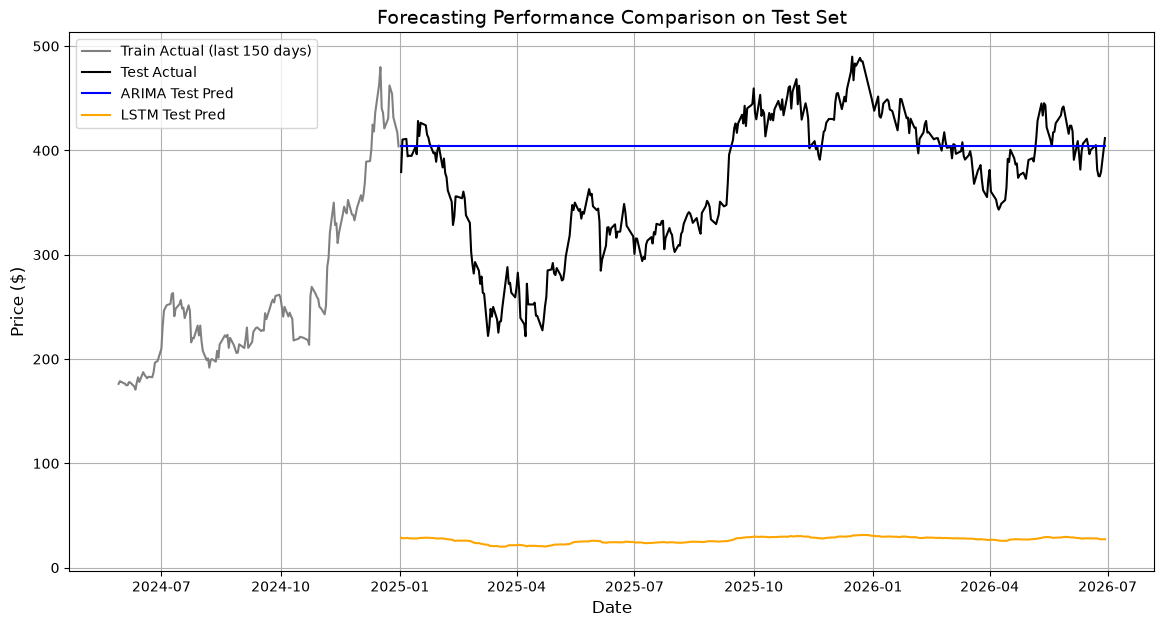

In [6]:
plt.figure(figsize=(14, 7))
plt.plot(train_close[-150:], label="Train Actual (last 150 days)", color='grey')
plt.plot(test_close, label="Test Actual", color='black')
plt.plot(arima_test_preds, label="ARIMA Test Pred", color='blue')
plt.plot(lstm_test_preds, label="LSTM Test Pred", color='orange')
plt.title("Forecasting Performance Comparison on Test Set", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

## 5. Task 3: Forecast Future Market Trends (Next 6-12 Months)
We fit the best-performing model on the full TSLA dataset and generate predictions for the next 6 months.

C:\Users\arsema\Desktop\New folder\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\arsema\Desktop\New folder\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\arsema\Desktop\New folder\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\arsema\Desktop\New folder\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No s

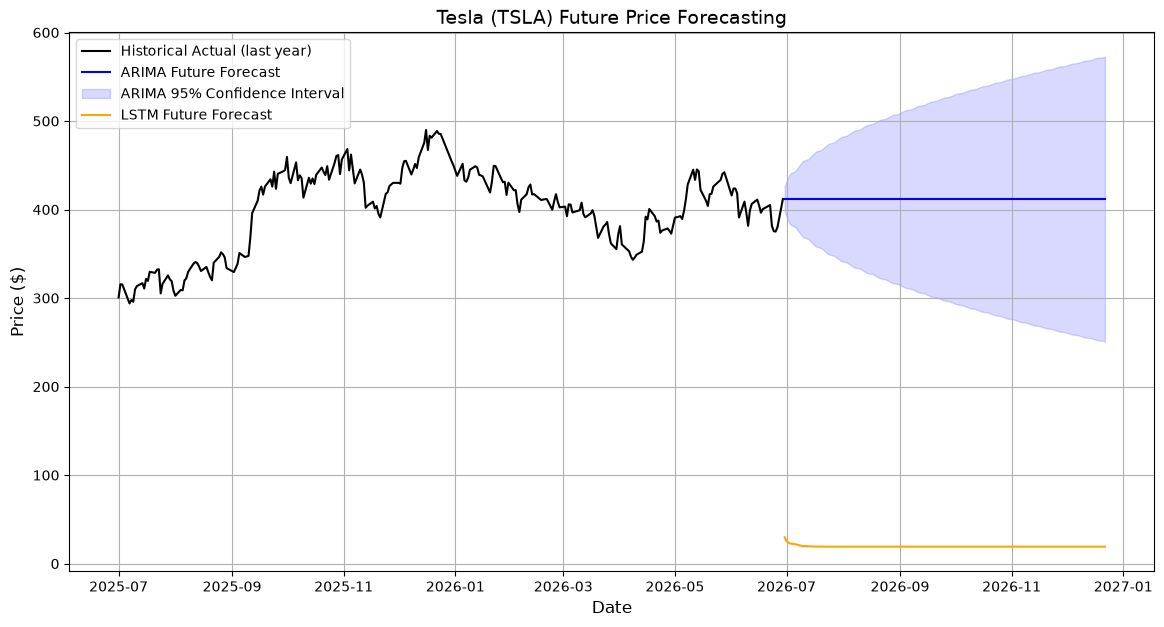

In [7]:
forecast_steps = 126 # ~6 months

# Fit ARIMA on full dataset
model_sm_full = SARIMAX(tsla_close, order=arima_order, seasonal_order=arima_seasonal_order)
fitted_sm_full = model_sm_full.fit(disp=False)

arima_future_forecast = fitted_sm_full.get_forecast(steps=forecast_steps)
arima_future_mean = arima_future_forecast.predicted_mean
arima_future_ci = arima_future_forecast.conf_int(alpha=0.05)

# Fit LSTM future (iterative rollout)
last_sequence_scaled = scaler.transform(tsla_close[-window_size:].values.reshape(-1, 1))
lstm_future_mean = forecast_lstm_future(lstm_model, last_sequence_scaled, forecast_steps, scaler, device)

future_dates = pd.date_range(start=tsla_close.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='B')
arima_future_mean.index = future_dates
arima_future_ci.index = future_dates
lstm_future_mean = pd.Series(lstm_future_mean, index=future_dates)

# Plot
plt.figure(figsize=(14, 7))
plt.plot(tsla_close[-250:], label="Historical Actual (last year)", color='black')
plt.plot(arima_future_mean, label="ARIMA Future Forecast", color='blue')
plt.fill_between(future_dates, arima_future_ci.iloc[:, 0], arima_future_ci.iloc[:, 1], color='blue', alpha=0.15, label="ARIMA 95% Confidence Interval")
plt.plot(lstm_future_mean, label="LSTM Future Forecast", color='orange')
plt.title("Tesla (TSLA) Future Price Forecasting", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()